# PyTorch RGB CNN model

## Notebook set-up

### Imports

In [ ]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets #, transforms

# Package imports
from image_classification_tools.pytorch import DataPipeline
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

### Hyperparameters

In [ ]:
# Model control
retrain_model = True   # Set to False to load existing model
model_source = 'local' # 'local' or 'huggingface'
preload_device = 'gpu'

# Hyperparameters
epochs = 25
learning_rate = 0.001
print_every = 250

## 1. Load and preprocess CIFAR-10 data

### 1.1. Visualize sample images

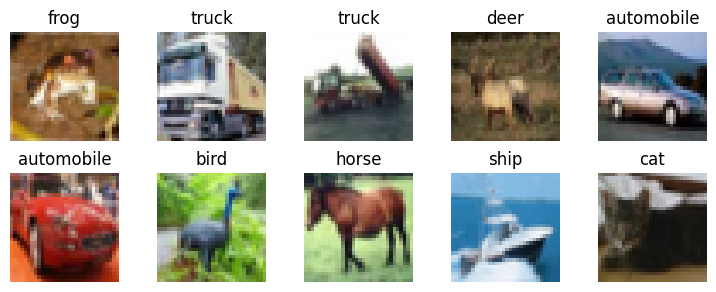

In [ ]:
# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(root=config.DATA_DIR, transform=config.RGB_TRANSFORM)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

### 1.2. Create data pipeline with RGB preprocessing

In [ ]:
# Create data pipeline with RGB preprocessing
loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split=config.SPLIT,
    train_transform=config.RGB_TRANSFORM,
    eval_transform=config.RGB_TRANSFORM,
    preload=preload_device,
    batch_size=config.BATCH_SIZE,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    root=config.DATA_DIR
).get_loaders()

# Display pipeline summary
print(loaders.split_info())

In [ ]:
# Unpack loaders for convenience
train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

## 2. Build CNN classifier with nn.Sequential

### 2.1. Define model architecture

In [ ]:
# Define model path
model_path = config.MODELS_DIR / 'rgb_cnn.pth'

# Load existing model if requested
if not retrain_model:

    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='rgb_cnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    # Try to load training history
    history = hf.load_history_from_source(
        model_path=model_path,
        model_name='rgb_cnn.pth',
        model_source=model_source
    )
    
    if model is None:
        print('Pretrained model not available, proceeding with training...')
        retrain_model = True
else:
    print('Training new model...')
    history = None

In [ ]:
if retrain_model:
    # Input: 3 x 32 x 32 (RGB)
    model = nn.Sequential(

        # Conv block 1: 3 -> 32 channels, 32x32 -> 16x16
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Dropout(0.25),
        
        # Classifier
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(32, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, len(config.CLASS_NAMES))

    ).to(config.DEVICE)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f'\nTotal parameters: {trainable_params}')

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.25, inplace=False)
  (8): AdaptiveAvgPool2d(output_size=(1, 1))
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=32, out_features=128, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 15786


### 2.2. Define loss function and optimizer

In [ ]:
if retrain_model:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### 2.3. Train model

In [ ]:
%%time

if retrain_model:
    history = training.train(
        model=model, 
        criterion=criterion, 
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader, 
        device=config.DEVICE, 
        epochs=epochs,
        print_every=print_every
    )
    print()
else:
    print('Training skipped - using loaded model')

Epoch   1/150 - loss: 1.8100 - acc: 31.12% - val_loss: 1.6464 - val_acc: 39.73%
Epoch  25/150 - loss: 1.1842 - acc: 57.66% - val_loss: 1.1128 - val_acc: 60.19%
Epoch  50/150 - loss: 1.0793 - acc: 61.58% - val_loss: 1.1723 - val_acc: 58.44%
Epoch  75/150 - loss: 1.0186 - acc: 63.66% - val_loss: 0.9687 - val_acc: 64.74%

Early stopping at epoch 95
Best val_loss: 0.9331 at epoch 85
Restored best model weights

CPU times: user 8min 25s, sys: 1.05 s, total: 8min 27s
Wall time: 8min 22s


### 2.4. Learning curves

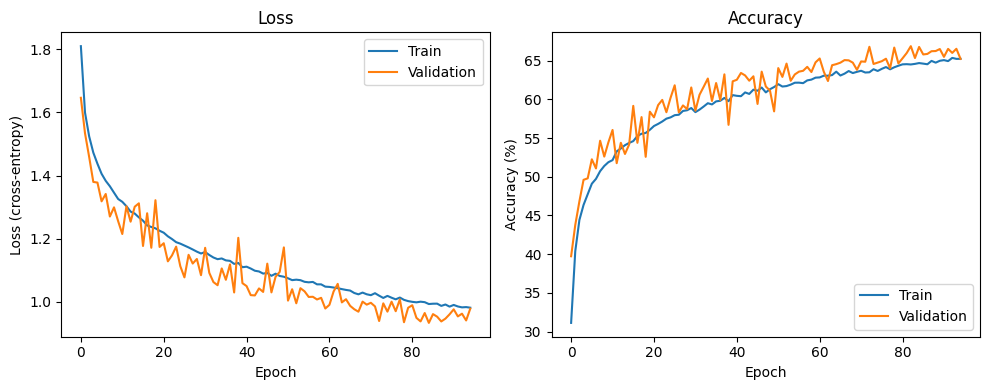

In [ ]:
if history is not None:
    fig, axes = plots.plot_learning_curves(history)
    plt.show()
else:
    print('No training history available')

## 3. Evaluate model on test set

### 3.1. Calculate test accuracy

In [ ]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 66.08%


### 3.2. Per-class accuracy

In [13]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 69.40%
automobile  : 84.90%
bird        : 47.40%
cat         : 46.00%
deer        : 53.30%
dog         : 57.30%
frog        : 83.70%
horse       : 58.90%
ship        : 82.70%
truck       : 77.20%


### 3.3. Confusion matrix

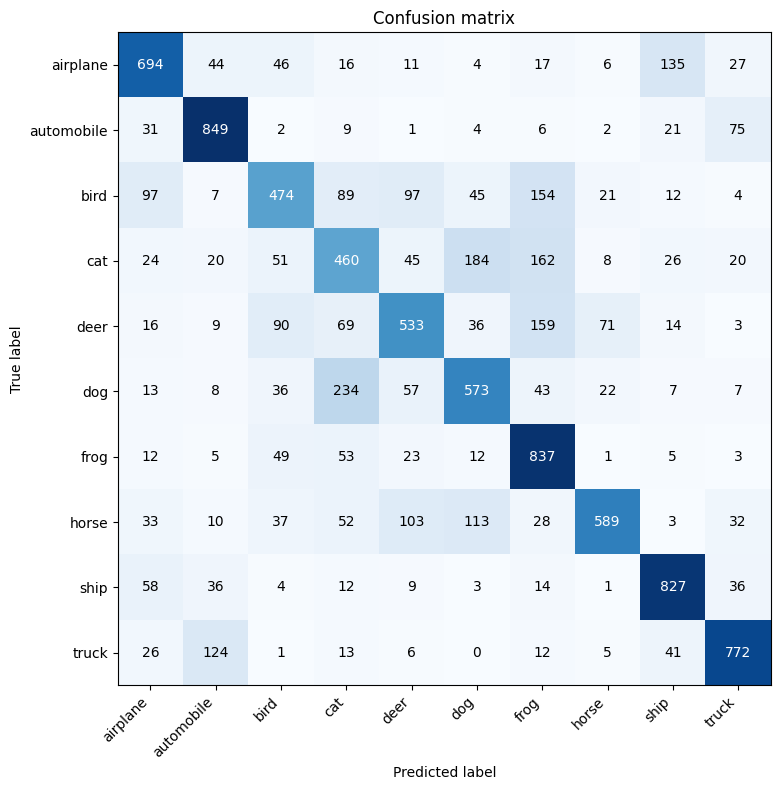

In [14]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 3.4. Predicted class probability distributions

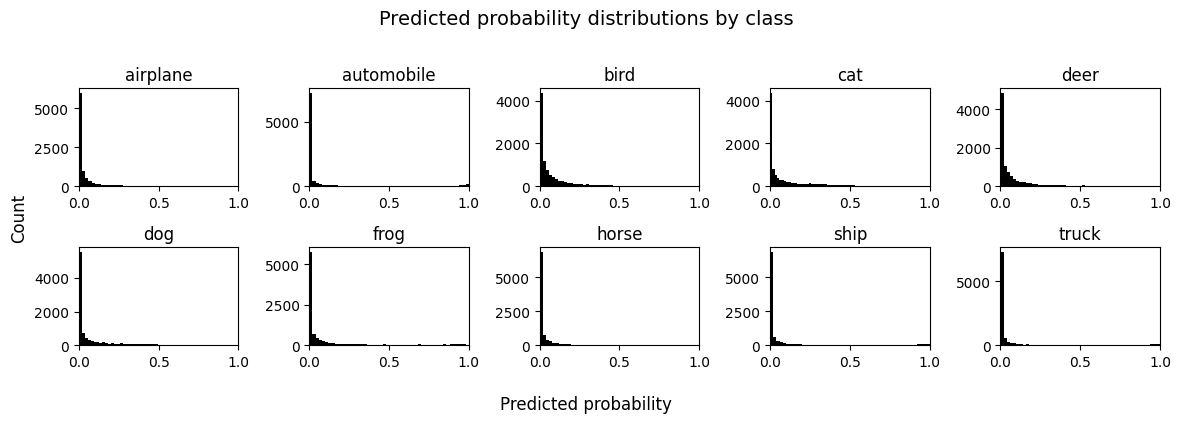

In [15]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()


### 3.5. Evaluation curves

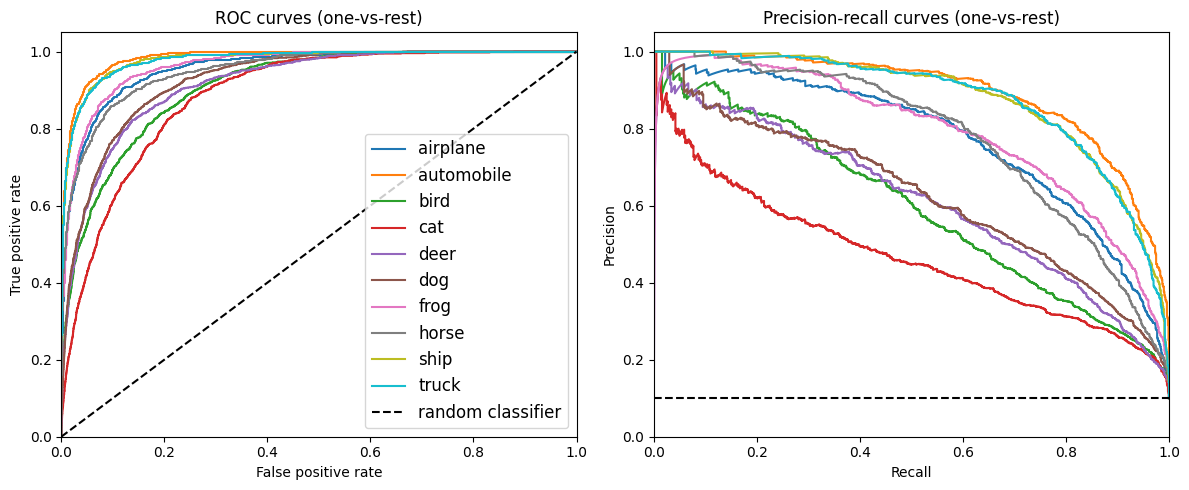

In [16]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 4. Save model

In [ ]:
if retrain_model:

    # Save trained model (and auto-upload to Hugging Face if configured)
    hf.save_and_upload_model(
        model=model,
        model_path=model_path,
        model_name='rgb_cnn.pth',
        history=history
    )

Model saved to: ../models/pytorch/rgb_cnn.pth
Test accuracy: 66.08%


### 4.1. Upload to Hugging Face Hub (optional)

In [ ]:
# Upload model to Hugging Face Hub
# Note: Run 'huggingface-cli login' first to authenticate

upload_to_hf = False  # Set to True to enable upload

if upload_to_hf:
    config.upload_to_huggingface(
        model_path=model_path,
        model_name='rgb_cnn.pth',
        commit_message=f'RGB CNN model - Test accuracy: {test_accuracy:.2f}%'
    )

## 5. Save test results for comparison

In [ ]:
# Save results path
results_path = config.RESULTS_DIR / 'rgb_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Trainable parameters: {trainable_params:,}')
print(f'  - Total parameters: {total_params:,}')

Test results saved to: ../data/pytorch/performance_results/rgb_cnn_results.pkl
  - Test accuracy: 66.08%
  - Trainable parameters: 15,786
  - Total parameters: 15,786
